### Overview

Perform PCA Analyasis on just the 2's and 6's from MNIST

In [1]:
import torch
from torchvision import datasets, transforms
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

Download MNIST dataset

In [2]:
mnist = datasets.MNIST(root='data', download=True)

In [4]:
X = mnist.data.numpy()
y = mnist.targets.numpy()

print(X.shape)
print(y.shape)


(60000, 28, 28)
(60000,)


Samples (2s and 6s): 11876
Original dimension: 784
Components for 90% variance: 84
Components for 95% variance: 147
Components for 99% variance: 312

Explained variance ratio for each dimension:
PC1: 0.105091
PC2: 0.080964
PC3: 0.076579
PC4: 0.051020
PC5: 0.043393
PC6: 0.035045
PC7: 0.032320
PC8: 0.028214
PC9: 0.025379
PC10: 0.023371
PC11: 0.020931
PC12: 0.019771
PC13: 0.017324
PC14: 0.015605
PC15: 0.015264
PC16: 0.014958
PC17: 0.013185
PC18: 0.012701
PC19: 0.011400
PC20: 0.011035
PC21: 0.010426
PC22: 0.009582
PC23: 0.009488
PC24: 0.009234
PC25: 0.008828
PC26: 0.008351
PC27: 0.008065
PC28: 0.007654
PC29: 0.007467
PC30: 0.006872
PC31: 0.006548
PC32: 0.006047
PC33: 0.005898
PC34: 0.005637
PC35: 0.005322
PC36: 0.005188
PC37: 0.005029
PC38: 0.004886
PC39: 0.004790
PC40: 0.004646
PC41: 0.004293
PC42: 0.004141
PC43: 0.004059
PC44: 0.003915
PC45: 0.003812
PC46: 0.003728
PC47: 0.003575
PC48: 0.003516
PC49: 0.003363
PC50: 0.003223
PC51: 0.003117
PC52: 0.003080
PC53: 0.003022
PC54: 0.002870
PC55

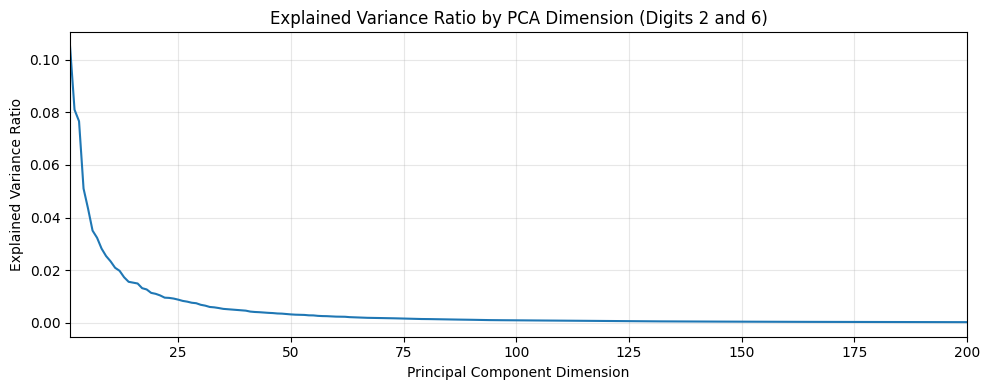

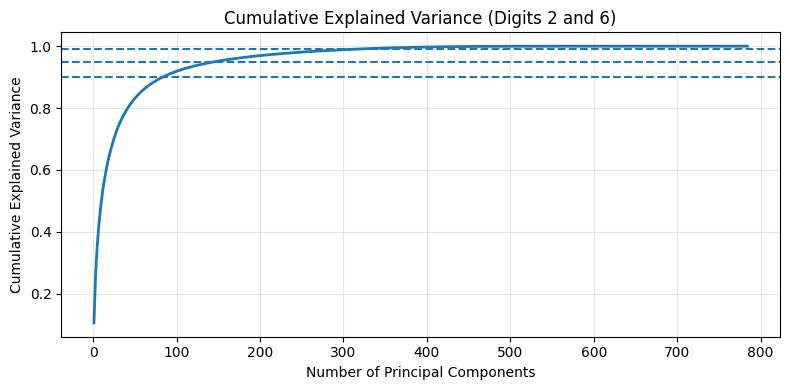

In [7]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Keep only digits 2 and 6
mask_26 = (y == 2) | (y == 6)
X_26 = X[mask_26]
y_26 = y[mask_26]

# Flatten images for PCA: (n_samples, 28, 28) -> (n_samples, 784)
X_26_flat = X_26.reshape(X_26.shape[0], -1).astype(np.float32)

# Standard PCA on centered data
pca = PCA()
pca.fit(X_26_flat)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Dimensionality estimates by retained variance
k90 = np.searchsorted(cumulative, 0.90) + 1
k95 = np.searchsorted(cumulative, 0.95) + 1
k99 = np.searchsorted(cumulative, 0.99) + 1

print(f"Samples (2s and 6s): {X_26_flat.shape[0]}")
print(f"Original dimension: {X_26_flat.shape[1]}")
print(f"Components for 90% variance: {k90}")
print(f"Components for 95% variance: {k95}")
print(f"Components for 99% variance: {k99}")

print("\nExplained variance ratio for each dimension:")
for dim, ratio in enumerate(explained, start=1):
    print(f"PC{dim}: {ratio:.6f}")

# Plot explained variance ratio for each principal component
dims = np.arange(1, len(explained) + 1)
plt.figure(figsize=(10, 4))
plt.plot(dims, explained, linewidth=1.5)
plt.xlim(1, 200)
plt.xlabel('Principal Component Dimension')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by PCA Dimension (Digits 2 and 6)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(dims, cumulative, linewidth=2)
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.axhline(0.99, linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance (Digits 2 and 6)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()